<a href="https://colab.research.google.com/github/sahel-datascience-projects/data-science-portfolio/blob/main/project-1-data-analysis/sales_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Sales Data Exploration with Python**


In [10]:
# ============================================================
# Project: Superstore Strategic Business Discovery (EDA)
# Goal: Uncover hidden sales patterns, analyze seasonal trends,
#       and identify key profitability drivers through data visualization.
# Tools: Python Data Stack (Pandas, Seaborn, Matplotlib)
# Author: Sahel
# ============================================================
from google.colab import files
uploaded = files.upload()

Saving sales.csv to sales (1).csv


In [11]:
# ============================================================
# STEP 1: DATA LOADING & INITIAL INSPECTION
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('sales.csv', encoding='latin1')

# Check for missing values and data types
print("--- Dataset Info ---")
print(df.info())

# Summary statistics for numerical columns
print("\n--- Descriptive Statistics ---")
display(df.describe())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [12]:
# ============================================================
# STEP 2: DATA CLEANING
# ============================================================
# Convert Date columns
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Drop duplicates if any
df = df.drop_duplicates()

Number of duplicate rows: 0


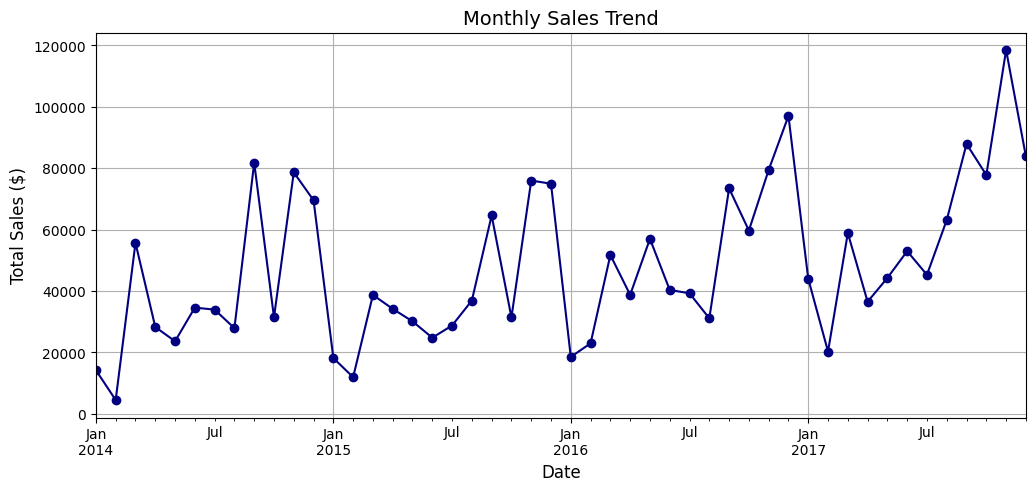

In [13]:
# ============================================================
# STEP 3: SALES TREND ANALYSIS
# ============================================================
# Extract Year and Month
df['Month_Year'] = df['Order Date'].dt.to_period('M')

# Group by month and sum sales
monthly_sales = df.groupby('Month_Year')['Sales'].sum()

plt.figure(figsize=(12, 5))
monthly_sales.plot(kind='line', marker='o', color='navy')
plt.title('Monthly Sales Trend', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.grid(True)
plt.show()

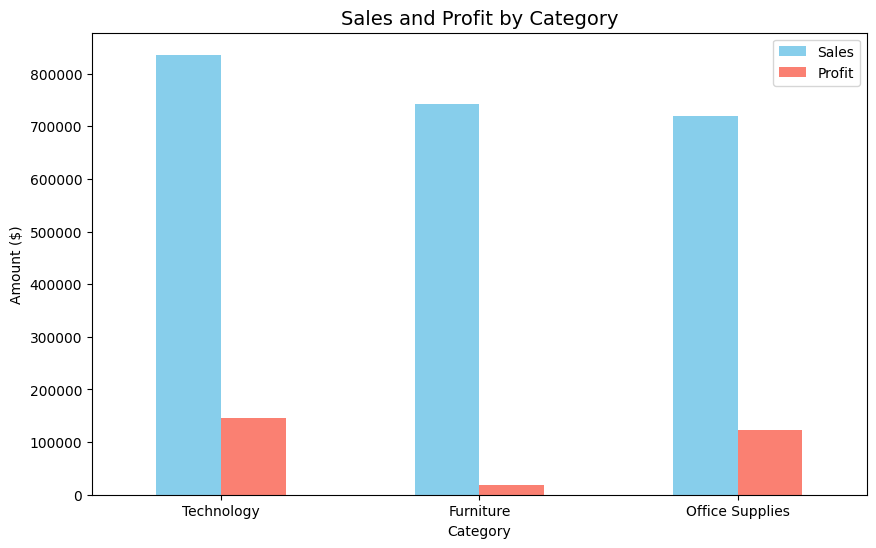

In [14]:
# ============================================================
# STEP 4: CATEGORY & SUB-CATEGORY PERFORMANCE
# ============================================================
category_analysis = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending=False)

category_analysis.plot(kind='bar', figsize=(10, 6), color=['skyblue', 'salmon'])
plt.title('Sales and Profit by Category', fontsize=14)
plt.ylabel('Amount ($)')
plt.xticks(rotation=0)
plt.show()

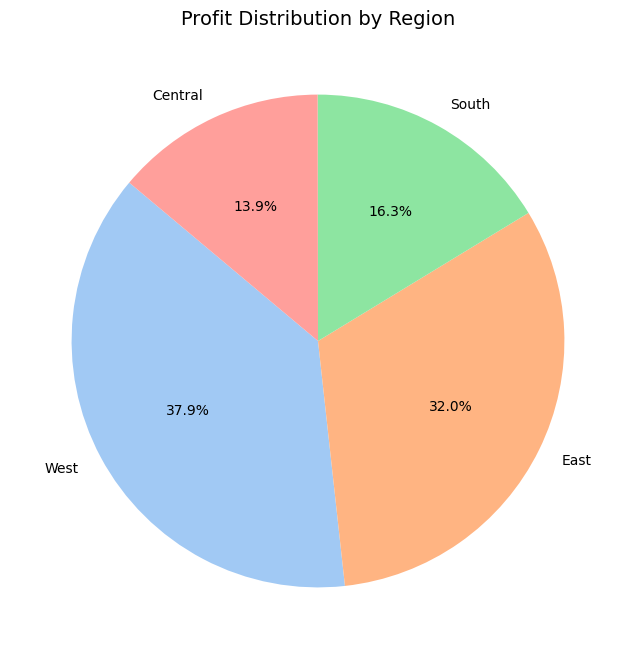

In [15]:
# ============================================================
# STEP 5: REGIONAL PROFITABILITY
# ============================================================
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 8))
plt.pie(region_profit, labels=region_profit.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Profit Distribution by Region', fontsize=14)
plt.show()

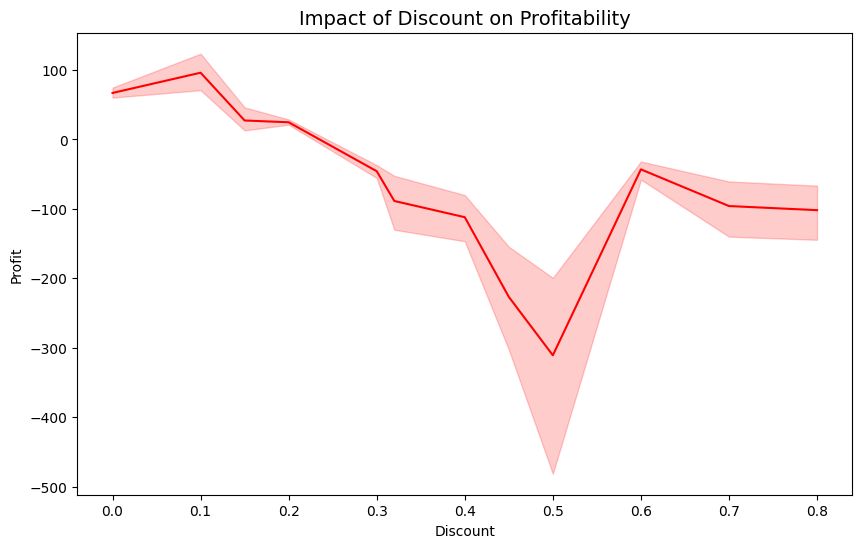

In [16]:
# ============================================================
# STEP 6: CORRELATION BETWEEN DISCOUNT & PROFIT
# ============================================================
plt.figure(figsize=(10, 6))
sns.lineplot(x='Discount', y='Profit', data=df, color='red')
plt.title('Impact of Discount on Profitability', fontsize=14)
plt.show()

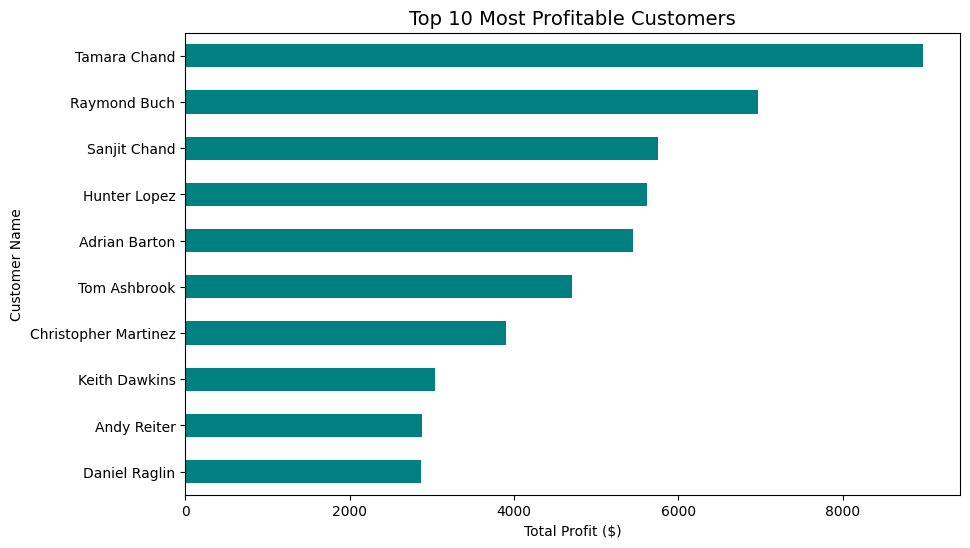

In [17]:
# ============================================================
# STEP 7: TOP 10 PROFITABLE CUSTOMERS
# ============================================================
top_customers = df.groupby('Customer Name')['Profit'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_customers.plot(kind='barh', color='teal')
plt.title('Top 10 Most Profitable Customers', fontsize=14)
plt.xlabel('Total Profit ($)')
plt.gca().invert_yaxis() # Highest profit on top
plt.show()

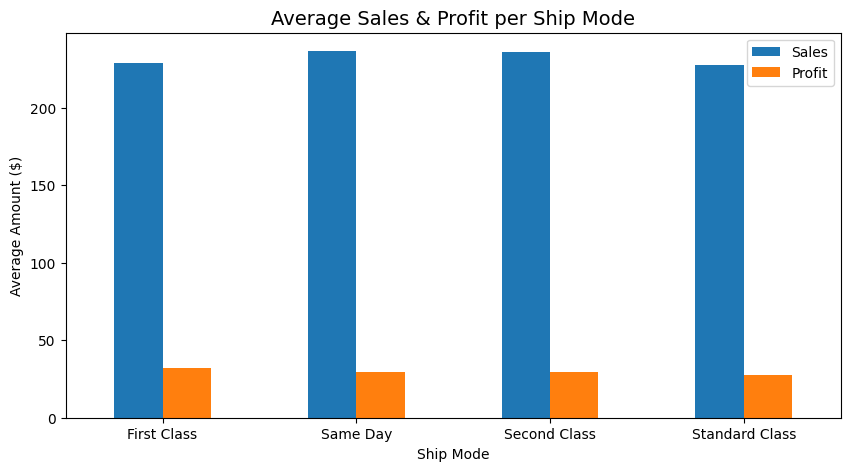

In [18]:
# ============================================================
# STEP 8: SHIP MODE VS PROFITABILITY
# ============================================================
ship_mode_analysis = df.groupby('Ship Mode')[['Sales', 'Profit']].mean()

ship_mode_analysis.plot(kind='bar', figsize=(10, 5))
plt.title('Average Sales & Profit per Ship Mode', fontsize=14)
plt.ylabel('Average Amount ($)')
plt.xticks(rotation=0)
plt.show()

In [19]:
# ============================================================
# STEP 9: CORRELATION MATRIX
# ============================================================
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation between Numerical Features', fontsize=14)
plt.show()

ValueError: could not convert string to float: 'CA-2016-152156'

<Figure size 800x600 with 0 Axes>

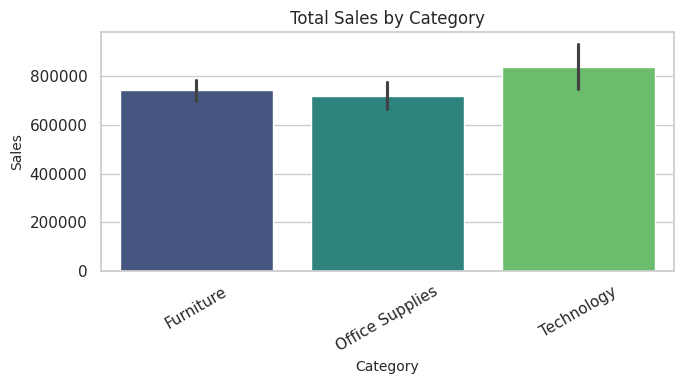

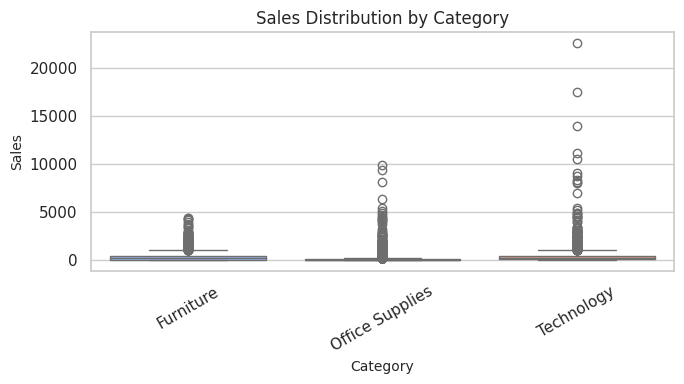

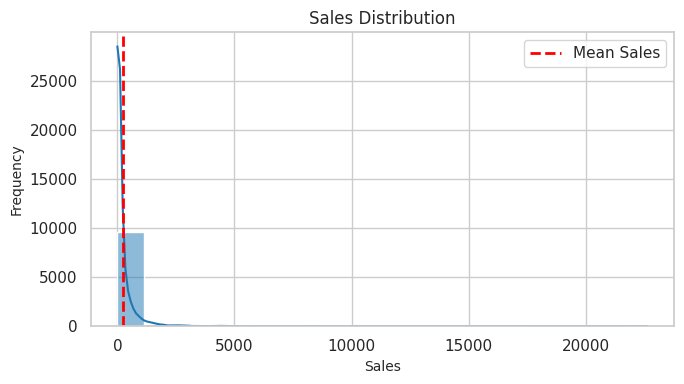

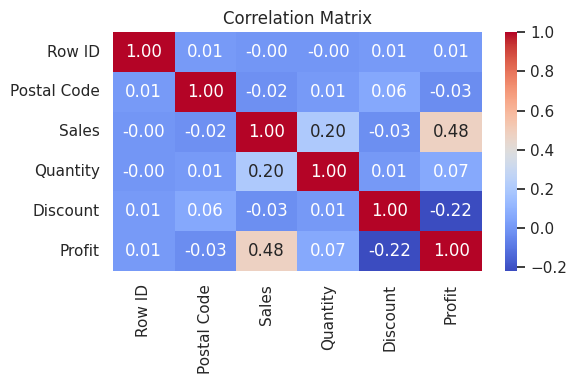

In [ ]:
# ==================================================
# Clean & Professional EDA (Compact Version)
# ==================================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
sns.set_context('notebook')

# ========================
# Data Cleaning
# ========================
df.drop_duplicates(inplace=True)
df['Sales'] = df['Sales'].fillna(df['Sales'].mean())

# ========================
# 1. Barplot (Smaller & Clean)
# ========================
plt.figure(figsize=(7,4))
sns.barplot(x='Category', y='Sales', hue='Category',
            data=df, estimator=sum, palette='viridis', legend=False)

plt.title('Total Sales by Category', fontsize=12)
plt.xlabel('Category', fontsize=10)
plt.ylabel('Sales', fontsize=10)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# ========================
# 2. Boxplot (Smaller & Clean)
# ========================
plt.figure(figsize=(7,4))
sns.boxplot(x='Category', y='Sales', hue='Category',
            data=df, palette='coolwarm', legend=False)

plt.title('Sales Distribution by Category', fontsize=12)
plt.xlabel('Category', fontsize=10)
plt.ylabel('Sales', fontsize=10)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# ========================
# 3. Histogram + Proper Mean Line
# ========================
plt.figure(figsize=(7,4))

sns.histplot(df['Sales'], bins=20, kde=True)

mean_sales = df['Sales'].mean()
plt.axvline(mean_sales, color='red', linestyle='--', linewidth=2, label='Mean Sales')

plt.title('Sales Distribution', fontsize=12)
plt.xlabel('Sales', fontsize=10)
plt.ylabel('Frequency', fontsize=10)

plt.legend()
plt.tight_layout()
plt.show()

# ========================
# 4. Correlation Heatmap
# ========================
df_numeric = df.select_dtypes(include=['number'])
correlation_matrix = df_numeric.corr()


plt.figure(figsize=(6,4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Matrix', fontsize=12)
plt.tight_layout()
plt.show()

## Key Insights

### 1. Sales Distribution
The distribution of sales is right-skewed, indicating that most transactions have relatively low sales values, while a small number of transactions contribute to very high sales. This suggests the presence of high-value orders that significantly impact total revenue.

### 2. Sales by Category
There is a clear difference in total sales across categories. One category dominates overall sales, indicating that it is the primary revenue driver for the business.

### 3. Regional Performance
Sales vary significantly across regions. Some regions generate much higher revenue than others, suggesting differences in customer demand, market size, or operational efficiency.

### 4. Average Sales by Category
The average sales per category reveal that some categories not only generate high total revenue but also have higher transaction values, making them more valuable per sale.

### 5. Data Quality
The dataset contains minimal missing values and a limited number of duplicate records, which were handled during the data cleaning phase to ensure reliable analysis.

### 6. Correlation Analysis
The correlation matrix shows relationships between numerical variables. Certain features have a positive correlation with sales, indicating potential factors influencing revenue.

## Conclusion

This analysis provides valuable insights into sales performance across different categories and regions.

The results show that a small number of high-value transactions contribute significantly to overall revenue. Additionally, certain product categories play a key role in driving sales, making them critical for business focus.

Regional differences highlight opportunities for growth in underperforming areas, while strong regions can be further optimized to maximize revenue.

From a business perspective, the company should:
- Focus on high-performing categories to maximize revenue
- Investigate underperforming regions to identify growth opportunities
- Leverage high-value transactions through targeted marketing strategies

Overall, this data-driven analysis supports better decision-making and helps identify areas for strategic improvement.